# GNN BASE 

* Autor: *Pablo Mendieta Ruiz*

En este cuarderno se define y entrena la GNN base. 

## 1. Intrducción 
Como bien se explica en este artículo, ​[23]​. Las GNN son un tipo de red neuronal diseñada específicamente para operar directamente sobre estructuras de tipo grafo. Este enfoque permite abordar tareas complejas como la clasificación de nodos, la predicción de enlaces o la caracterización del grafo completo, algo difícil de conseguir con redes tradicionales. 

Una de las principales ventajas de las GNN es su capacidad para trabajar con datos que no presentan una estructura regular, como ocurre con las imágenes o el texto. A diferencia de estos formatos, los grafos no tienen una disposición espacial fija, ni una secuencia ordenada clara como en el lenguaje natural. Esto representa un desafío para las redes neuronales tradicionales, especialmente para las redes convolucionales. 

No obstante, las GNN están fuertemente inspiradas en las CNN, ya que también aplican un concepto análogo a la convolución. En lugar de analizar píxeles vecinos como en una imagen, las GNN procesan cada nodo del grafo teniendo en cuenta la información de sus nodos adyacentes. De este modo, la red agrega, transforma y propaga la información entre los nodos conectados, permitiendo aprender representaciones significativas de cada nodo y del grafo en su conjunto.​[24]​ 

### 1.1. Explicación del Algoritmo utilizado. 

Las Redes Nueronales Gráficas, se nutren de la información de los nodos vecinos o adyacentes, para ir contruyendo, cada arista y cada nodo, su propia información. Para ello, se va a tomar a cada arista y nodo como un embedding, de información importante para el conjunto del grafo, este embedding se va a ir mejorarndo a medida de que se entrene la red para acabar con un valor de probabilidad de cada arista de estar o no en el tour óptimo. 

#### **Capa Inicial**
**Creación de los Embeddings:**

Se va a empezar definiendo un embedding, y explicando su utlidad en las GNN. Los embeddings son representaciones numéricas de objetos, en este caso, de aristas y nodos de un grafo en forma de vector. Son muy útiles en el caso del procesamiento de lenguaje, debido a que palabras similares o que tienen gran relación en un texto, se encuentran cercanas entre ellas. 

En el caso de la construcción del tour óptimo, los embeddings de la GNN  van cambiando época a época para acabar decicidiendo para cada arista que probabilidad tiene de estar o no en el tour óptimo. Para ello, se procede a explicar cómo se construyen: 

La red se alimenta con las coordenadas (x,y) de cada nodo y con los valores de las aristas de su nodo inicio, nodo final y de su distancia euclidiana. Sin embargo, esta información es excasa para la red, por lo que necesitamos llevar esta información a un espacio latante de tamaño de la variable *hidden_dim* (valor constante). Para ello se ejucta un MLP para hacer una transformación lineal. Este MLP está formado por una Capa Lineal, una capa de BatchNor1d y una ReLU. 

* **Capa Lineal:** 
    - Entrada: un vector de dimenensión pequeña, por ejemplo, en el caso de los nodos de dimensión 2, los valores de las coordenadas (x,y). 
    - Salida: un vector de dimensión de la variable *hidden_dim*, por ejemplo 128. 
    - Matemáticame: 
            ....

* **BatchNorm1d:** 

    Esta capa sirve para normalizar los valores, es decir que tengan una media cercana a 0 y una varianza similar a 1. Este proceso sirve para estabilizar el entrenamiento y que los valores de cada dimension latente no se disparen, es decir, ni se vaya a infinito, ni se acerquen mucho a cero. 

* **ReLU (Rectified Linear Unit):**

    Matemáticamente: ReLU(u) = max(0,u), aplicándolo componente a componente. 
    Esta capa nos elimina la linealidad que pudieran tener los resultados, haciendo que la red pueda aproximar funciones no lineales.


**Resultado:**

Con esta secuencia a partir de las características de los nodos y aristas, se han creado los *"embedding inciales"* pasando de dim 2 o 3, a dim 128. Con esta represtanción la GNN ya puede ser entrenada e ir modicando y refinando los embeddings.


#### **Capa UPDATE**

La capa *MetaLayer* actua como un bloque organizado que coordina dos fases sucesivas de actualización dentro de la GNN:

- **Aristas:** 
    Para actualizar el embedding de una arista, la capa recoge las representaciones de su nodo origen y final. Con esta información la fusiona con su propia información, es decir genera una representación que responde a: ¿Cómo es el nodo que genera el mensaje (nodo inicio)?¿Cómo soy yo (arista)?¿Cómo es el nodo que recibe el mensaje?. Esta información generada pasa a través de un MLP, que toma como entrada una representación de tamaño 3 * *hidden_dim*, y tiene coma salida el nuevo embedding de la arista de dimensión *hidden_dim*. Al final, para evitar la perder por completo la información inicial, se suma al embedding el vector que tenía la arista antes de comenzar. 

- **Nodos:** 
    Para cada nodo del grafo, reunimos los mensajes de las aristas, ya actualizados en el paso anterior, que están conectadas con ese nodo. Para resumir toda esa información en un vextor de tamaño *hidden_dim* hace una media ponderada, dando mayor valor a las aristas con mayor peso. Con esta representación concatenada a la media de los embeddings de los nodos orígenes de cada arista, pasa a través de un MLP, que tiene como entrada un embdding de tamaño 2 * *hidden_dim* y devuelve un embedding de tamaño *hidden_dim*, que responde a las preguntas: ¿Cómo es el nodo *i*?¿Cómo es la arista que uni *i* con *j*? 

    Hasta este punto, el nodo tiene un embedding que resume toda la información de sus vecinos, ahora se concatena esa información, con la representación del nodo. Esto entra en el segundo MLP que tiene como entrada un embedding de tamaño 2 * *hiden_dim* y como salida un embedding de tamaño *hiddn_dim* que añadiendo una suma residual de la representación del nodo al inicio para no perder toda la información. Se forma el nuevo embedding del nodo. 








## 2. Código del Algoritmo

**Importación de librerias**

In [1]:
# Llamadas a función de otros archivos, que serán utilizados en el código. (explicados en sus respectivos archivos .py)
import dataset
import importlib
importlib.reload(dataset)
from dataset import DatasetCreation, FamousTSP

import solutions
importlib.reload(solutions)
from solutions import SolutionAnalysys, Opt

import inicializacion_pesos
importlib.reload(inicializacion_pesos)
from inicializacion_pesos import apply_init

In [2]:
# Librerías necesarias 
import numpy as np 
import random
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import os
import gc
import pandas as pd
import itertools
from torchinfo import summary
import networkx as nx

# Pytorch 
import torch
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.transforms as T
from torch.nn import Sequential as Seq, Linear as Lin, ReLU, BatchNorm1d
from torch_geometric.utils import scatter
from torch_geometric.nn import MetaLayer
from torch import Tensor

### 2.1. Carga de datos y preprocesamiento 

La base de datos ha sido generada en el archivo *creacion_dataset.py*. Consta de 1000 problemas TSP, de 5, 10, 12 y 15 nodos. Estos problemas son creados con la siguente estructura (explicada en el archivo *crecion_dataset.py*) para su posterior implementación en la GNN. 


In [4]:
# descarga de la Base de Datos 
data_list = torch.load("TSP_data/tsps1000.pt", weights_only=False)

In [5]:
# Estructura de un TSP de la base de datos: 

ejemplo = data_list[0] # Ejemplo de un TSP de 5 nodos

print("Nodos del problema:")
print(ejemplo.x.tolist())
print("\nAristas por donde pasa el tour (1 si para , 0 si no pasa):")
print(ejemplo.y.tolist())
print("\nCamino más corto")
print(ejemplo.true_path.tolist())
print("\nDistancia total del tour:")
print(ejemplo.true_distance.tolist()[0][0])
print("\nPeso para la red neuronal:")
print(ejemplo.pos_class_weight)

Nodos del problema:
[[40.72846603393555, 33.576290130615234], [71.94888305664062, 11.545259475708008], [68.049560546875, 6.516124725341797], [66.26758575439453, 37.31504821777344], [63.9853515625, 11.13711166381836]]

Aristas por donde pasa el tour (1 si para , 0 si no pasa):
[[0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [1.0], [0.0], [1.0], [0.0], [0.0], [0.0], [1.0], [0.0], [0.0], [0.0], [0.0]]

Camino más corto
[0.0, 3.0, 1.0, 2.0, 4.0]

Distancia total del tour:
97.0348129272461

Peso para la red neuronal:
4.0


Separación de la base de datos en Train: 70%, Test: 20% y Val: 10%

In [7]:
tamanio = len(data_list) # tamaño de la base de datos 

train_len = int(tamanio * 0.7) # 70 % para train
val_len = int(tamanio * 0.1) # 10 % para val 

mezclar_datos = random.sample(data_list, len(data_list)) # Mezcla de la base de datos 

lista_train = mezclar_datos[:train_len]
lista_val = mezclar_datos[train_len:train_len + val_len]
lista_test = mezclar_datos[train_len + val_len:] # 20 % para test 

Creación de lotes de datos, con *train_list*, *val_list* y *test_list*. Cada lote contiene problemas del mismo tamaño, para facilitar a la GNN el entrenamiento.

In [8]:
max_batch = 256  
train_data = []

# Ordena train_list por tamaño de nodos 
orden_datos = sorted(lista_train, key=lambda x: x.num_nodes)

for dataset in orden_datos:
    if not train_data or train_data[-1][-1].num_nodes != dataset.num_nodes:
        # Batch vacío o número de nodos diferentes, se crea otro batch
        train_data.append([dataset])
    else:
        # Batch de mismo número de nodos y con espacio, añade el TSP
        batch_actual = train_data[-1]
        if sum(data.num_nodes for data in batch_actual) + dataset.num_nodes <= max_batch:
            batch_actual.append(dataset)
        else:
            # Si no tiene espacio, crea otro batch
            train_data.append([dataset])

# Mismo procedimiento para los datos de validación 
val_data = []
orden_datos = sorted(lista_val, key=lambda x: x.num_nodes)

for dataset in orden_datos:
    if not val_data or val_data[-1][-1].num_nodes != dataset.num_nodes:
        val_data.append([dataset])
    else:
        batch_actual = val_data[-1]
        if sum(data.num_nodes for data in batch_actual) + dataset.num_nodes <= max_batch:
            batch_actual.append(dataset)
        else:
            val_data.append([dataset])


# Mismo procedimiento para los datos de test
test_data = []
orden_datos = sorted(lista_test, key=lambda x: x.num_nodes)

for dataset in orden_datos:
    if not test_data or test_data[-1][-1].num_nodes != dataset.num_nodes:
        test_data.append([dataset])
    else:
        batch_actual = test_data[-1]
        if sum(data.num_nodes for data in batch_actual) + dataset.num_nodes <= max_batch:
            batch_actual.append(dataset)
        else:
            test_data.append([dataset])

# Creación de los generadores de datos 
train_generador = DataLoader(train_data, batch_size=None, shuffle=True)
val_generador= DataLoader(val_data, batch_size=None, shuffle=True)
test_generador = DataLoader(test_data, batch_size=None, shuffle=True)
            

### 2.2 Creación de la GNN 

En este apartado están definifidas las funciones y capas necesarias para la creación y entrenamiento de la GNN. 

* la clase **Aristas** se encarga de actualizar los embeddings de cada arista en función de: 

    - El embedding del nodo origen. 
    - El embedding del nodo destino.
    - El embedding previo de la propia arista.

Para ello concatena los 3 embeddings y aplica un Multilayer Perceptron (MLP), junto con un sesgo de las características previas de la arista, genera la nueva representación de esta. 

In [3]:
class Aristas(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # Multiplicamos el vector por 3 debido a que es una concatenación de 3 vectores de la info de cada nodo: 
        #  1. src: Representación del nodo origen. 
        #  2. dst: Representación del nodo destino. 
        #  3. arista_emb: atributos actuales de la arista. 
        dimension = ( 3 * hidden_dim )

        # Red Neuronal pequeña, de una capa: BatchNorm1d(3 * hidden_dim) -> Relu() -> Linear(hidden_dim)
        self.edge_mlp = Seq(BatchNorm1d(dimension),
                            ReLU(),
                            Lin(dimension, hidden_dim,bias=False))

    # Actualiza la información de los nodos 
    def forward(self, src, dst, arista_emb, peso_arista,  batch):
        out = torch.cat([src, arista_emb,dst], 1)

        return self.edge_mlp(out) + arista_emb # transforma la arista usando MLP y lo suma a la representación original.
    

* La clase **Nodos** sse encarga de actualizar los valores de los nodos de cada problema. Toma para casda nodo los embeddings de sus vecinos y las característcas de las aristas que los unen.

    - El MLP 1: Calcula el mensaje que cada arista envía desde su nodo origen hacia el nodo destino. 
    - El MLP 2: Junto con el embbeding del nodo, más el mensaje de los nodos vecinos (MLP 1), genera la nueva representación del nodo. 
    

In [4]:
class Nodos(torch.nn.Module):
    def __init__(self,hidden_dim):
        super().__init__()
        # Concatena 2 vectores de tamaño hidden_dim. 
        # Caso mlp1:  
        #  1. x[row]: representación del nodo origen de cada arista. 
        #  2. arista_emb: representación de la arista. 
        # Caso mlp2: 
        #  1. x: representación original del nodo. 
        #  2. out: vector de agregar los mensajes de los nodos vecinos (MLP 1).

        dimension = ( 2 * hidden_dim)

        
        self.node_mlp_1 = Seq(BatchNorm1d(dimension),
                              ReLU(),
                              Lin(dimension, hidden_dim)
                              )
        self.node_mlp_2 = Seq(BatchNorm1d(dimension),
                              ReLU(),
                              Lin(dimension, hidden_dim))

    def forward(self, x, edge_index, arista_emb, peso_arista, batch):
        # x: Representación de los nodos
        # edge_index: qué nodos están conectados 
        # arista_emb: Representación de las aristas 
        # peso_arista: Peso de cada arista 

        # Nodos de origen y destino 
        row, col = edge_index

        '''Información agragada desde nodos vecinos '''
        # Calcula el mensaje que manda el nodo origen al nodo destino. 
        out = torch.cat([x[row], arista_emb], dim=1)
        out = self.node_mlp_1(out)

        # Junta todos los mensajes que le llegan al nodo destino y hace una media ponderada. 
        out = scatter(peso_arista*out, col, dim=0, dim_size=x.size(0), reduce='mean')
        out = torch.cat([x, out], dim=1)

        return self.node_mlp_2(out) + x

* La clase **Update**  agrupa en una sola capa, la lógica de "mensaje - agregado - actualización" en aristas y nodos (usando las anteriores clases)

In [5]:
class Update(torch.nn.Module):

    # Llamadas a los módulos explicados antes 
    def __init__(self,edge_model,node_model):
        super(Update, self).__init__()
        self.edge_model = edge_model
        self.node_model = node_model

    def forward(
        self,
        x: Tensor,
        edge_index: Tensor,
        arista_emb: Optional[Tensor] = None,
        peso_arista: Optional[Tensor] = None,
        batch: Optional[Tensor] = None,
    ) -> Tuple[Tensor, Optional[Tensor], Optional[Tensor]]:

        row = edge_index[0]
        col = edge_index[1]

        # Calcular los nuevos atributos de las aristas
        if self.edge_model is not None:
            arista_emb = self.edge_model(x[row], x[col], arista_emb, peso_arista, batch if batch is None else batch[row])

        # Actuliza los nodos, en función de: estado actual, mensajes de vecinos(aristas), contexto global
        if self.node_model is not None:
            x = self.node_model(x, edge_index, arista_emb, peso_arista, batch)

        return x, arista_emb,  # nodos, aristas y vector del grafo completo 

* La clase **GNN** es la estructura completa de la **GNN**, donde podemos oberservar las capas de la red: 

    - Preprocesamiendto de los nodos
    - Dos capas de propagración de mensajes: Metalayer
    - Decodificador para predecir si la arista pertenece al tour 
    - Capa finala para puntuar cada arista

In [6]:
class GNN(torch.nn.Module):

    # Transfromación de los datos 
    def __init__(self,node_input_dim, edge_input_dim, hidden_dim, decoder, use_edge_weight=True):
        super(GNN, self).__init__()
        self.lin0_edge = Seq(Lin(edge_input_dim, hidden_dim,bias=False),
                             BatchNorm1d(hidden_dim),
                             ReLU()) 
        
        self.lin0_node = Seq(Lin(node_input_dim, hidden_dim,bias=False),
                             BatchNorm1d(hidden_dim),
                             ReLU())

        # Decodifadores 
        self.edge_lin1 = Lin((hidden_dim), hidden_dim) # embeddings de aristas 
        self.node_lin1 = Lin((hidden_dim*2), hidden_dim) # embeddings de nodos 
        self.nodes_edge_lin1 = Lin((hidden_dim*3), hidden_dim) # nodo1 + arista + nodo2
        self.lin2 = Lin(hidden_dim, 1) #Salida final

        # Parámetros de Control 
        self.decoder = decoder 
        self.use_edge_weight=use_edge_weight # Pesos de las aristas 

        '''Capas de Update'''
        self.metalayer = Update(Aristas(hidden_dim), Nodos(hidden_dim))
        self.metalayer2 = Update(Aristas(hidden_dim), Nodos(hidden_dim))


    def forward(self, x, edge_index, arista_emb, peso_arista, batch):
        arista_emb = self.lin0_edge(arista_emb)
        x = self.lin0_node(x)

        # Normalización de datos 
        if self.use_edge_weight==True and peso_arista is not None:
            peso_arista = torch.ones(arista_emb.shape[0],1)

        # Propagación de mensajes 
        x, arista_emb = self.metalayer(x, edge_index, arista_emb, peso_arista, batch)
        x, arista_emb = self.metalayer2(x, edge_index, arista_emb, peso_arista, batch)

        # En función delvalor de self.decoder, se decide cómo predecir si una arista está en el tour 
        if self.decoder=='edge_nodes_emb': # combina nodos y aristas 
            row, col = edge_index
            z = torch.cat([x[row], arista_emb, x[col]], dim=-1)
            out = self.nodes_edge_lin1(z)

        else:
            raise ValueError('Possible decoder is edge_nodes_emb')

        if "inner_product" not in self.decoder:
            out = self.lin2(out)

        return out

**Estructura de la Red Neuronal Gráfica**

Una vez ya explicadas todas las clases necesarias, se procede a la creación de la Red Neuronal Gráfica, en este caso, para poder imprimirla y ver la estructura de la misma. Se van a añadir unos hiperparámetros de ejemplo: 

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === PARÁMETROS DEL MODELO ===
node_input_dim = 2
edge_input_dim = 1
hidden_dim = 128
use_edge_weight = True
num_epochs = 32

# === INSTANCIAR MODELO ===
model = GNN(node_input_dim=node_input_dim,
                             edge_input_dim=edge_input_dim,
                             hidden_dim=hidden_dim,
                             decoder="edge_nodes_emb",  
                             use_edge_weight=use_edge_weight
                            )

model.to(device)

optimizador = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

criterio = torch.nn.BCEWithLogitsLoss(reduction='none')

pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters: {pytorch_total_params}')

# === CREAR ENTRADAS DE EJEMPLO ===
num_nodes = 12
num_edges = num_nodes * (num_nodes - 1)  # grafo dirigido completo

x = torch.rand((num_nodes, node_input_dim))
edge_index = torch.tensor(list(itertools.permutations(range(num_nodes), 2)), dtype=torch.long).T
arista_emb = torch.rand((num_edges, edge_input_dim))
peso_arista = torch.ones((num_edges, 1))
batch = torch.zeros(num_nodes, dtype=torch.long)

# === MOSTRAR ESTRUCTURA DEL MODELO ===

summary(
    model,
    input_data=(x, edge_index, arista_emb, peso_arista, batch),
    depth=4,           
    col_names=["input_size", "output_size", "num_params"],
    col_width=20,
    row_settings=["var_names"]
)

Number of parameters: 333185


Layer (type (var_name))                  Input Shape          Output Shape         Param #
GNN (GNN)                                [12, 2]              [132, 1]             49,408
├─Sequential (lin0_edge)                 [132, 1]             [132, 128]           --
│    └─Linear (0)                        [132, 1]             [132, 128]           128
│    └─BatchNorm1d (1)                   [132, 128]           [132, 128]           256
│    └─ReLU (2)                          [132, 128]           [132, 128]           --
├─Sequential (lin0_node)                 [12, 2]              [12, 128]            --
│    └─Linear (0)                        [12, 2]              [12, 128]            256
│    └─BatchNorm1d (1)                   [12, 128]            [12, 128]            256
│    └─ReLU (2)                          [12, 128]            [12, 128]            --
├─Update (metalayer)                     [12, 128]            [12, 128]            --
│    └─Aristas (edge_model)              

* La función **train** se encarga del entrenamiendo del modelo, siendo de las más complejas. Sus funciones son las siguientes: 

    1. Para cada batch(lote):
        - Llama a la GNN para obtener la variable *out* (puntuación de cada arista).
        - Calcula la péridida binaria por arista. 
        - Construye un vector de pesos que penaliza a las aristas positivas. 
        - Reconstruye "mapas de calor" de predicciones y rutas para cada grafo. 
        - Calcula las métricas L1 de "distancia al tour óptimo" y "gap porcentual". 
    
    2. Valores de salida: 
        - valor de pérdida.
        - Promedio de la métrica L1 de distancia. 
        - Promedio del gap. 



In [8]:
def train(train_generador):

    model.train() # Modo de entrenamiento 
    l1_path_distances = 0 # Suma de las distancias promedio del tour
    l1_optimality_gaps = 0 # sua de los gap (qué tan lejos está del tour óptimo)

    for train_data in train_generador:  # Iterate in batches over the training dataset.
        train_data.x = train_data.x.to(device)
        train_data.edge_index= train_data.edge_index.to(device)
        train_data.edge_attr = train_data.edge_attr.to(device)
        train_data.edge_weight = train_data.edge_weight.to(device)
        train_data.batch = train_data.batch.to(device)
        out = model(train_data.x, train_data.edge_index,train_data.edge_attr, train_data.edge_weight, train_data.batch)
        train_loss = criterio(out, train_data.y.to(device))  # Compute the loss.

        batch_weights = torch.ones(train_loss.shape)

        mask = train_data.y.bool()  # Add a dimension to match the shape of ones_tensor
        batch_weights[mask.squeeze()] *= train_data.pos_class_weight[0]

        train_loss = train_loss * batch_weights.to(device)
        train_loss = train_loss.sum() / batch_weights.sum()

        train_loss.backward()  # Derive gradients.
        optimizador.step()  # Update parameters based on gradients.
        optimizador.zero_grad()  # Clear gradients.

        for_view = int(train_data.num_nodes/train_data.num_graphs)
        batch_out_heat_map=out.view((train_data.num_graphs, for_view,for_view))
        batch_truth_heat_map=train_data.true_path.view((train_data.num_graphs, for_view))
        batch_peso_arista=train_data.edge_weight.view((train_data.num_graphs, for_view, for_view))
        batch_true_distancess =  train_data.true_distance.view((train_data.num_graphs))

        l1_path_distance, l1_gap = SolutionAnalysys.mean_per_batch_optimality_metrics(batch_out_heat_map, batch_truth_heat_map, train_data.num_graphs, for_view, batch_peso_arista, batch_true_distancess)
        l1_path_distances += l1_path_distance
        l1_optimality_gaps += l1_gap

    return train_loss, l1_path_distances/len(train_generador), l1_optimality_gaps/len(train_generador)


* La función **test** se encarga de evaluar al modelo. Para ello, recorre los lotes de test, calculando: 

    1. Test_loss: pérdida del último *batch* procesado. 
    2. La distancia L1 promedio entre tour predicho y tour óptimo. 
    3. El gap de optimalidad promedio. 

In [9]:
import torch
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import networkx as nx

def test(loader, threshold=0.5):
    model.eval()
    total_loss = 0.0
    l1_path_distances = 0.0
    l1_optimality_gaps = 0.0

    # Para métricas de clasificación
    all_probs = []
    all_labels = []

    # Para tour length
    total_tour_len = 0.0
    total_graphs = 0

    for data in loader:
        # — Mover datos a device —
        for attr in [
            'x','edge_index','edge_attr','edge_weight',
            'batch','y','true_path','true_distance',
            'pos_class_weight'
        ]:
            setattr(data, attr, getattr(data, attr).to(device))

        # — Forward y loss con pesos de clase —
        out = model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.edge_weight,
            data.batch
        )
        loss_raw = criterio(out, data.y)
        weights = torch.ones_like(loss_raw)
        mask = data.y.bool().squeeze()
        weights[mask] *= data.pos_class_weight[0]
        loss = (loss_raw * weights).sum() / weights.sum()
        total_loss += loss.item()

        # — Métricas de optimalidad (todos torch.Tensor) —
        B = data.num_graphs
        V = int(data.num_nodes / B)
        out_map    = out.view(B, V, V).cpu().detach()         
        truth_map  = data.true_path.view(B, V).cpu().detach()
        edge_wmat  = data.edge_weight.view(B, V, V).cpu().detach()
        true_dists = data.true_distance.view(B).cpu().detach()

        l1_dist, l1_gap = SolutionAnalysys.mean_per_batch_optimality_metrics(
            out_map, truth_map, B, V, edge_wmat, true_dists
        )
        l1_path_distances  += l1_dist
        l1_optimality_gaps += l1_gap

        # — Acumular para clasificación —
        probs  = torch.sigmoid(out).cpu().detach().view(-1)
        labels = data.y.cpu().detach().view(-1)
        all_probs.append(probs)
        all_labels.append(labels)

        # — Reconstruir tour y suma de longitudes —
        for b in range(B):
            G = nx.Graph()
            G.add_nodes_from(range(V))
            mat_prob = out_map[b]
            mat_w     = edge_wmat[b]

            for i in range(V):
                for j in range(i+1, V):
                    G.add_edge(
                        i, j,
                        weight=mat_w[i, j].item(),
                        prob=mat_prob[i, j].item()
                    )

            tour = list(nx.approximation.greedy_tsp(G, weight='weight'))

            # Intentamos sumar la longitud, o fallback a true_dists
            tour_len = 0.0
            cyclic = tour[1:] + [tour[0]] if len(tour) > 1 else []
            for u, v in zip(tour, cyclic):
                if G.has_edge(u, v):
                    tour_len += G[u][v]['weight']
                else:
                    # Si falta la arista, usamos la distancia real como fallback
                    tour_len = true_dists[b].item()
                    break

            total_tour_len += tour_len
            total_graphs   += 1

    # — Cálculo final de métricas de clasificación —
    all_probs  = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    precision  = precision_score(
        all_labels, (all_probs > threshold).astype(int)
    )
    recall     = recall_score(
        all_labels, (all_probs > threshold).astype(int)
    )
    auc        = roc_auc_score(all_labels, all_probs)
    avg_tour_len = total_tour_len / total_graphs

    N = len(loader)
    return (
        total_loss/N,
        l1_path_distances/N,
        l1_optimality_gaps/N,
        precision,
        recall,
        auc,
        avg_tour_len
    )

### 2.3 Entrenamiento de la GNN

Se va a entrenar el modelo, y guardar información del mismo de cada época para su posterior análisis.

In [14]:
train_losses = []
val_losses   = []
test_losses  = []

train_l1_opt_gaps = []
val_l1_opt_gaps   = []
test_l1_opt_gaps  = []

val_precisions = []
val_recalls    = []
val_aucs       = []
val_tour_lens  = []

for epoch in range(num_epochs+1):
    # — Entrenamiento —
    train_loss, train_l1, train_gap = train(train_generador)

    # — Validación —
    (val_loss,
     val_l1,
     val_gap,
     val_prec,
     val_rec,
     val_auc,
     val_tour_len) = test(val_generador)

    # — Test final (solo loss/L1/gap) —
    test_loss, test_l1, test_gap = test(test_generador)[:3]

    # — Impresión cada 5 epochs —
    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d}")
        print(f"\tTrain loss: {train_loss:.4f}  L1: {train_l1:.4f}  gap: {train_gap:.4f}")
        print(f"\tVal   loss: {val_loss:.4f}  L1: {val_l1:.4f}  gap: {val_gap:.4f}")
        print(f"\t       Prec: {val_prec:.4f}  Rec: {val_rec:.4f}  AUC: {val_auc:.4f}")
        print(f"\tTest  loss: {test_loss:.4f}  L1: {test_l1:.4f}  gap: {test_gap:.4f}\n")

    # — Almacenamiento para graficar después —
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    test_losses.append(test_loss)

    train_l1_opt_gaps.append(train_gap)
    val_l1_opt_gaps.append(val_gap)
    test_l1_opt_gaps.append(test_gap)

    val_precisions.append(val_prec)
    val_recalls.append(val_rec)
    val_aucs.append(val_auc)
    val_tour_lens.append(val_tour_len)


Epoch 000
	Train loss: 0.8690  L1: 6.9942  gap: 0.1789
	Val   loss: 0.5232  L1: 7.4756  gap: 0.2339
	       Prec: 0.2011  Rec: 0.7870  AUC: 0.8172
	Test  loss: 0.5076  L1: 7.8864  gap: 0.2392

Epoch 005
	Train loss: 0.7130  L1: 6.5237  gap: 0.1333
	Val   loss: 0.4884  L1: 6.3764  gap: 0.1302
	       Prec: 0.2476  Rec: 0.8394  AUC: 0.8692
	Test  loss: 0.4711  L1: 6.7740  gap: 0.1202

Epoch 010
	Train loss: 0.4282  L1: 5.6947  gap: 0.0730
	Val   loss: 0.4991  L1: 5.7219  gap: 0.0772
	       Prec: 0.3148  Rec: 0.7111  AUC: 0.8759
	Test  loss: 0.4723  L1: 6.0571  gap: 0.0771

Epoch 015
	Train loss: 0.3253  L1: 5.6756  gap: 0.0748
	Val   loss: 0.4968  L1: 5.4953  gap: 0.0684
	       Prec: 0.2900  Rec: 0.7607  AUC: 0.8727
	Test  loss: 0.4666  L1: 5.7505  gap: 0.0651

Epoch 020
	Train loss: 0.3783  L1: 5.6456  gap: 0.0703
	Val   loss: 0.4933  L1: 5.3636  gap: 0.0651
	       Prec: 0.2857  Rec: 0.7798  AUC: 0.8743
	Test  loss: 0.4614  L1: 5.6706  gap: 0.0641

Epoch 025
	Train loss: 0.3126  L1: 

**Gráficas de información del modelo**

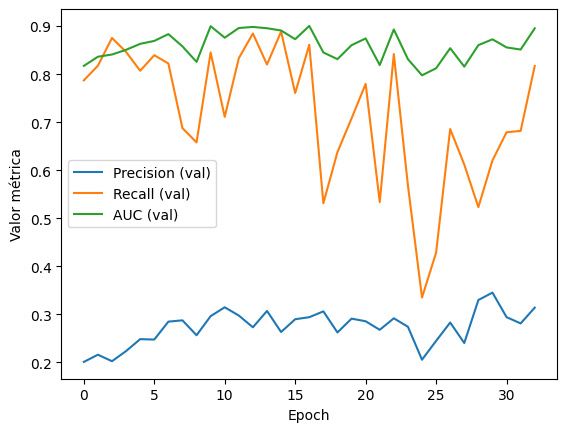

In [ ]:
import matplotlib.pyplot as plt

plt.plot(val_precisions, label="Precision (val)")
plt.plot(val_recalls,    label="Recall (val)")
plt.plot(val_aucs,       label="AUC (val)")
plt.xlabel("Epoch")
plt.ylabel("Valor métrica")
plt.legend()
plt.show()

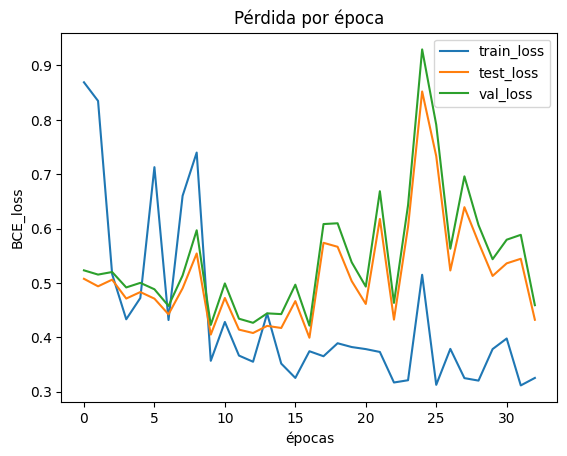

In [16]:
# Asegurarnos de que cada valor sea un float
train_vals = [t.item() if hasattr(t, 'item') else float(t) for t in train_losses]
val_vals   = [t.item() if hasattr(t, 'item') else float(t) for t in val_losses]
test_vals  = [t.item() if hasattr(t, 'item') else float(t) for t in test_losses]

plt.plot(train_vals, label='train_loss')
plt.plot(test_vals,  label='test_loss')
plt.plot(val_vals,   label='val_loss')
plt.xlabel('épocas')
plt.ylabel('BCE_loss')
plt.title('Pérdida por época')
plt.legend()
plt.show()


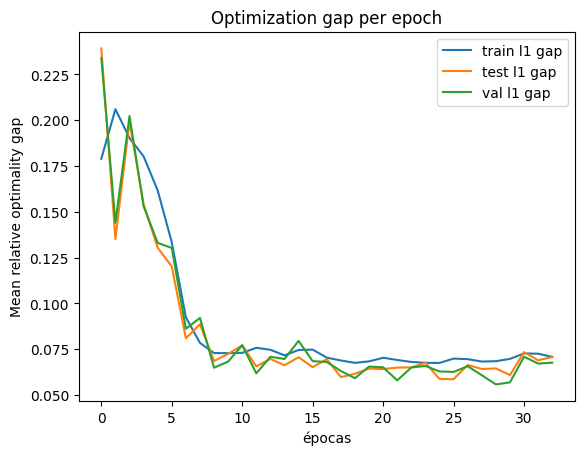

In [17]:
# Gráfica de porcentaje de gap medio por época
plt.plot(train_l1_opt_gaps,label='train l1 gap')
plt.plot(test_l1_opt_gaps,label='test l1 gap')
plt.plot(val_l1_opt_gaps,label='val l1 gap')
plt.xlabel('épocas')
plt.ylabel('Mean relative optimality gap')
plt.title("Optimization gap per epoch")
plt.legend()
plt.show()

**Búsqueda de Hiperparámetros**

Una vez visto cómo fuciona la red neuronal, se va a hacer un entrenamiento de varios modelos, modficando los hiperparámetros para posteriormente compararlos y continuar el proceso con el que mejor resultados dé. 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Parámetros fijos ===
edge_input_dim = 1
node_input_dim = 2
use_edge_weight = True

# === Hiperparámetros a probar ===
hidden_dims = [128]
num_epochs_list = [32, 64]
lrs = [0.001, 0.0005]
weight_decays = [0.0001, 0.00005]
decoders = ["edge_nodes_emb"]

# === Carpeta para guardar modelos ===
save_dir = "trained_models_base"
os.makedirs(save_dir, exist_ok=True)

# === Resultados ===
results = []

# === Probar todas las configuraciones ===
configs = list(itertools.product(hidden_dims, num_epochs_list, lrs, weight_decays, decoders))

for i, (hidden_dim, num_epochs, lr, weight_decay, decoder) in enumerate(configs):
    print(f"\nEntrenando modelo {i+1}/{len(configs)}")
    print(f"→ hidden_dim={hidden_dim}, epochs={num_epochs}, lr={lr}, weight_decay={weight_decay}, decoder='{decoder}'")

    # === Crear modelo y objetos globales ===
    model = GNN(node_input_dim,
                edge_input_dim,
                hidden_dim,
                decoder=decoder,
                use_edge_weight=use_edge_weight).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr,
                                 weight_decay=weight_decay)
    
    criterion = torch.nn.BCEWithLogitsLoss(reduction='none')

    # === Métricas por época ===
    train_losses = []
    val_losses = []
    test_losses = []
    train_l1_opt_gaps = []
    val_l1_opt_gaps = []
    test_l1_opt_gaps = []
    val_precisions = []
    val_recalls = []
    val_aucs = []
    val_avg_tour_lens = []
    test_precisions = []
    test_recalls = []
    test_aucs = []
    test_avg_tour_lens = []

    # === Bucle de entrenamiento ===
    for epoch in range(num_epochs):
        model.train()
        train_loss, train_l1_path_dist, train_opt_gap = train(train_generador)
        # Validación dentro del loop si lo deseas...
        model.eval()
        val_metrics = test(val_generador)   # Devuelve 7 valores
        train_losses.append(train_loss)
        val_losses.append(val_metrics[0])
        val_l1_opt_gaps.append(val_metrics[2])
        val_precisions.append(val_metrics[3])
        val_recalls.append(val_metrics[4])
        val_aucs.append(val_metrics[5])
        val_avg_tour_lens.append(val_metrics[6])

        test_metrics = test(test_generador)
        test_losses.append(test_metrics[0])
        test_l1_opt_gaps.append(test_metrics[2])
        test_precisions.append(test_metrics[3])
        test_recalls.append(test_metrics[4])
        test_aucs.append(test_metrics[5])
        test_avg_tour_lens.append(test_metrics[6])

        if epoch % 5 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {(epoch+1):03d}:")
            print(f"  Train loss: {train_loss:.4f} | Val loss: {val_metrics[0]:.4f} | Test loss: {test_metrics[0]:.4f}")
            print(f"  Val gap: {val_metrics[2]:.4f} | Test gap: {test_metrics[2]:.4f}")
            print(f"  Val AUC: {val_metrics[5]:.4f} | Test AUC: {test_metrics[5]:.4f}")

    # === Guardar modelo ===
    model_filename = f"model_{i+1}_hd{hidden_dim}_lr{lr}_ep{num_epochs}_dec_{decoder}.pt"
    model_path = os.path.join(save_dir, model_filename)
    torch.save(model.state_dict(), model_path)

    # === Guardar resumen final de métricas ===
    results.append({
        "modelo": i + 1,
        "hidden_dim": hidden_dim,
        "num_epochs": num_epochs,
        "lr": lr,
        "weight_decay": weight_decay,
        "decoder": decoder,
        "train_loss": train_losses[-1],
        "val_loss": val_losses[-1],
        "test_loss": test_losses[-1],
        "val_opt_gap": val_l1_opt_gaps[-1],
        "test_opt_gap": test_l1_opt_gaps[-1],
        "val_precision": val_precisions[-1],
        "val_recall": val_recalls[-1],
        "val_auc": val_aucs[-1],
        "val_avg_tour_len": val_avg_tour_lens[-1],
        "test_precision": test_precisions[-1],
        "test_recall": test_recalls[-1],
        "test_auc": test_aucs[-1],
        "test_avg_tour_len": test_avg_tour_lens[-1],
        "model_path": model_path
    })

    # === Limpiar para siguiente modelo ===
    del model, optimizer, criterion
    torch.cuda.empty_cache()
    gc.collect()

# === Guardar resumen a CSV ===
df = pd.DataFrame(results)
df.to_csv("resultados_entrenamiento_completo.csv", index=False)


* Para saber cuál es el modelo que más conviene, se hace una **comparación de resultados** donde se busca el modelo con menor gap, es decir, el modelo en el que de media, se aleje menos del tour óptimo. 

In [ ]:
# === Carga el CSV con tus resultados previos ===
df = pd.read_csv("resultados_entrenamiento_GNN.csv")

records = []

for _, row in df.iterrows():
    hidden_dim = int(row["hidden_dim"])
    decoder    = row["decoder"]
    model_path = row["model_path"]

    # Reconstruye y carga el modelo en la variable global `model`
    model = GNN(
        node_input_dim=2,
        edge_input_dim=1,
        hidden_dim=hidden_dim,
        decoder=decoder,
        use_edge_weight=True
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))

    # Ahora `test(loader)` usará este `model`, tu `criterion` y `device`
    model.eval()
    with torch.no_grad():
        new_test_loss, new_test_l1_dist, new_test_opt_gap = test(test_generador)

    records.append({
        "modelo":           row["modelo"],
        "hidden_dim":       hidden_dim,
        "num_epochs":       int(row["num_epochs"]),
        "lr":               float(row["lr"]),
        "weight_decay":     float(row["weight_decay"]),
        "decoder":          decoder,
        "prev_test_loss":   float(row["test_loss"]),
        "new_test_loss":    new_test_loss.item(),
        "new_test_l1_dist": new_test_l1_dist,
        "new_test_opt_gap": new_test_opt_gap,
        "model_path":       model_path
    })

# Construye y ordena el DataFrame
comp_df = pd.DataFrame(records).sort_values("new_test_opt_gap")
print(comp_df.to_string(index=False))
comp_df.to_csv("comparacion_modelos.csv", index=False)
print("\nComparación guardada en 'comparacion_modelos.csv'")


 modelo  hidden_dim  num_epochs     lr  weight_decay        decoder  prev_test_loss  new_test_loss  new_test_l1_dist new_test_opt_gap                                                        model_path
      2         128          32 0.0010       0.00010 edge_nodes_emb        0.391352       0.433235          5.196194   tensor(0.0544)   trained_models\model_2_hd128_lr0.001_ep32_dec_edge_nodes_emb.pt
      6         128          32 0.0005       0.00010 edge_nodes_emb        0.373398       0.789424          5.262586   tensor(0.0564)  trained_models\model_6_hd128_lr0.0005_ep32_dec_edge_nodes_emb.pt
      8         128          32 0.0005       0.00005 edge_nodes_emb        0.390088       0.459575          5.257847   tensor(0.0568)  trained_models\model_8_hd128_lr0.0005_ep32_dec_edge_nodes_emb.pt
     12         128          64 0.0010       0.00005 edge_nodes_emb        0.391036       0.411499          5.107666   tensor(0.0577)  trained_models\model_12_hd128_lr0.001_ep64_dec_edge_nodes_emb.pt


### 2.4 Pruebas de la GNN 

Después de comprobar que el modelo con menor gap, es el 2. Se procede a hacer una prueba para comprobar cómo funciona.

* Prueba gráfica con 15 tsps de 5 a 16 nodos

In [16]:
# descarga de la Base de Datos de pruebas 
data_prueba = torch.load("TSP_data/tsp_pruebas.pt", weights_only=False)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carga del modelo 
model = GNN(2, 1, 128, decoder="edge_nodes_emb", use_edge_weight=True).to(device)
model.load_state_dict(torch.load(
    "trained_models/model_2_hd128_lr0.001_ep32_dec_edge_nodes_emb.pt",
    map_location=device
))
model.eval()

# Listas para guardar resultados
coords_list       = []  
tour_uncross_list = []  
true_path_list    = []  
pred_dist_list    = [] 
true_dist_list    = []  
num_nodes_list    = []  

for idx, ejemplo in enumerate(data_prueba):
    # 1) Extraer coordenadas, matriz de distancias y solución óptima de este ejemplo
    coords_tensor    = ejemplo.x                
    dist_matrices    = ejemplo.disntace_matrices
    true_path_tensor = ejemplo.true_path        
    true_distance_t  = ejemplo.true_distance    
    
    # Convertimos a tipos Python / NumPy cuando haga falta:
    coords = coords_tensor.to(device)  # para el modelo, lo mantenemos en device
    num_nodes = coords.shape[0]
    
    # Distancia óptima como float
    if torch.is_tensor(true_distance_t):
        true_distance = true_distance_t.view(-1).cpu().item()
    else:
        true_distance = float(true_distance_t)
    
    # El camino óptimo como lista de ints (solo para imprimir más tarde)
    true_path = true_path_tensor.view(-1).tolist()
    
    # Recogemos la matriz de distancias: dist_matrices puede ser lista/tensor
    if isinstance(dist_matrices, (list, tuple)):
        dist_mat = dist_matrices[0]
    else:
        dist_mat = dist_matrices[0]
    
    # 3) Construir el grafo completo (las aristas i≠j)
    edges = [(i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)  
    
    # 4) Para cada arista (i,j) extraemos dist_mat[i,j] y formamos edge_attr, edge_weight
    edge_attr_list = []
    for (i, j) in edges:
        dij = dist_mat[i, j].item() if torch.is_tensor(dist_mat) else dist_mat[i][j]
        edge_attr_list.append([dij])
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float).to(device)     
    edge_weight = edge_attr.clone() 
    
    # Preparamos el objeto Data de PyG
    batch = torch.zeros(num_nodes, dtype=torch.long).to(device)
    data = Data(
        x          = coords,         
        edge_index = edge_index,     
        edge_attr  = edge_attr,      
        edge_weight= edge_weight,    
        batch      = batch           
    )
    
    # Forward de la red para obtener logits → probs
    with torch.no_grad():
        logits = model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.edge_weight,
             data.batch
        )
        probs = torch.sigmoid(logits).view(-1).cpu().numpy() 
    
    # Reconstrucción del tour predicho 
    tour_pred = SolutionAnalysys.tour_from_probs(probs, num_nodes)
    coords_py = coords_tensor.cpu().tolist()  
    uncorner = Opt(coords_py)
    tour_pred= uncorner.uncross(tour_pred)
    
    # 9) Calcular distancia total del tour descruzado
    dist_pred = 0.0
    for k in range(len(tour_pred) - 1):
        i, j = tour_pred[k], tour_pred[k + 1]
        d_ij = dist_mat[i, j].item() if torch.is_tensor(dist_mat) else dist_mat[i][j]
        dist_pred += d_ij

    coords_list.append(coords_tensor.cpu())    
    tour_uncross_list.append(tour_pred)
    true_path_list.append(true_path)
    pred_dist_list.append(dist_pred)
    true_dist_list.append(true_distance)
    num_nodes_list.append(num_nodes)
    
    # 10) Imprimir resultados para esta instancia
    print(f"\n—— TSP {idx+1}/{len(data_prueba)} :")
    print(f"Tour predicho : {tour_pred}")
    print(f"Tour óptimo:  {true_path}")
    print(f"Distancia predicha: {dist_pred:.2f}   |   Distancia óptima: {true_distance:.2f}")
    print(f"Gap relativo: {abs((dist_pred - true_distance)/true_distance * 100):.2f}%")


—— TSP 1/12 :
Tour predicho : [0, 4, 2, 3, 1, 0]
Tour óptimo:  [0.0, 1.0, 3.0, 2.0, 4.0]
Distancia predicha: 209.00   |   Distancia óptima: 209.00
Gap relativo: 0.00%

—— TSP 2/12 :
Tour predicho : [0, 1, 5, 4, 2, 3, 0]
Tour óptimo:  [0.0, 1.0, 5.0, 4.0, 2.0, 3.0]
Distancia predicha: 266.40   |   Distancia óptima: 266.40
Gap relativo: 0.00%

—— TSP 3/12 :
Tour predicho : [0, 5, 2, 4, 3, 1, 6, 0]
Tour óptimo:  [0.0, 5.0, 2.0, 4.0, 3.0, 1.0, 6.0]
Distancia predicha: 217.74   |   Distancia óptima: 217.74
Gap relativo: 0.00%

—— TSP 4/12 :
Tour predicho : [0, 3, 1, 5, 7, 6, 2, 4, 0]
Tour óptimo:  [0.0, 3.0, 1.0, 5.0, 7.0, 6.0, 2.0, 4.0]
Distancia predicha: 238.15   |   Distancia óptima: 238.15
Gap relativo: 0.00%

—— TSP 5/12 :
Tour predicho : [0, 3, 5, 4, 6, 2, 7, 8, 1, 0]
Tour óptimo:  [0.0, 8.0, 1.0, 4.0, 6.0, 2.0, 7.0, 5.0, 3.0]
Distancia predicha: 200.32   |   Distancia óptima: 183.74
Gap relativo: 9.02%

—— TSP 6/12 :
Tour predicho : [0, 3, 4, 1, 9, 2, 5, 8, 7, 6, 0]
Tour óptimo:  [

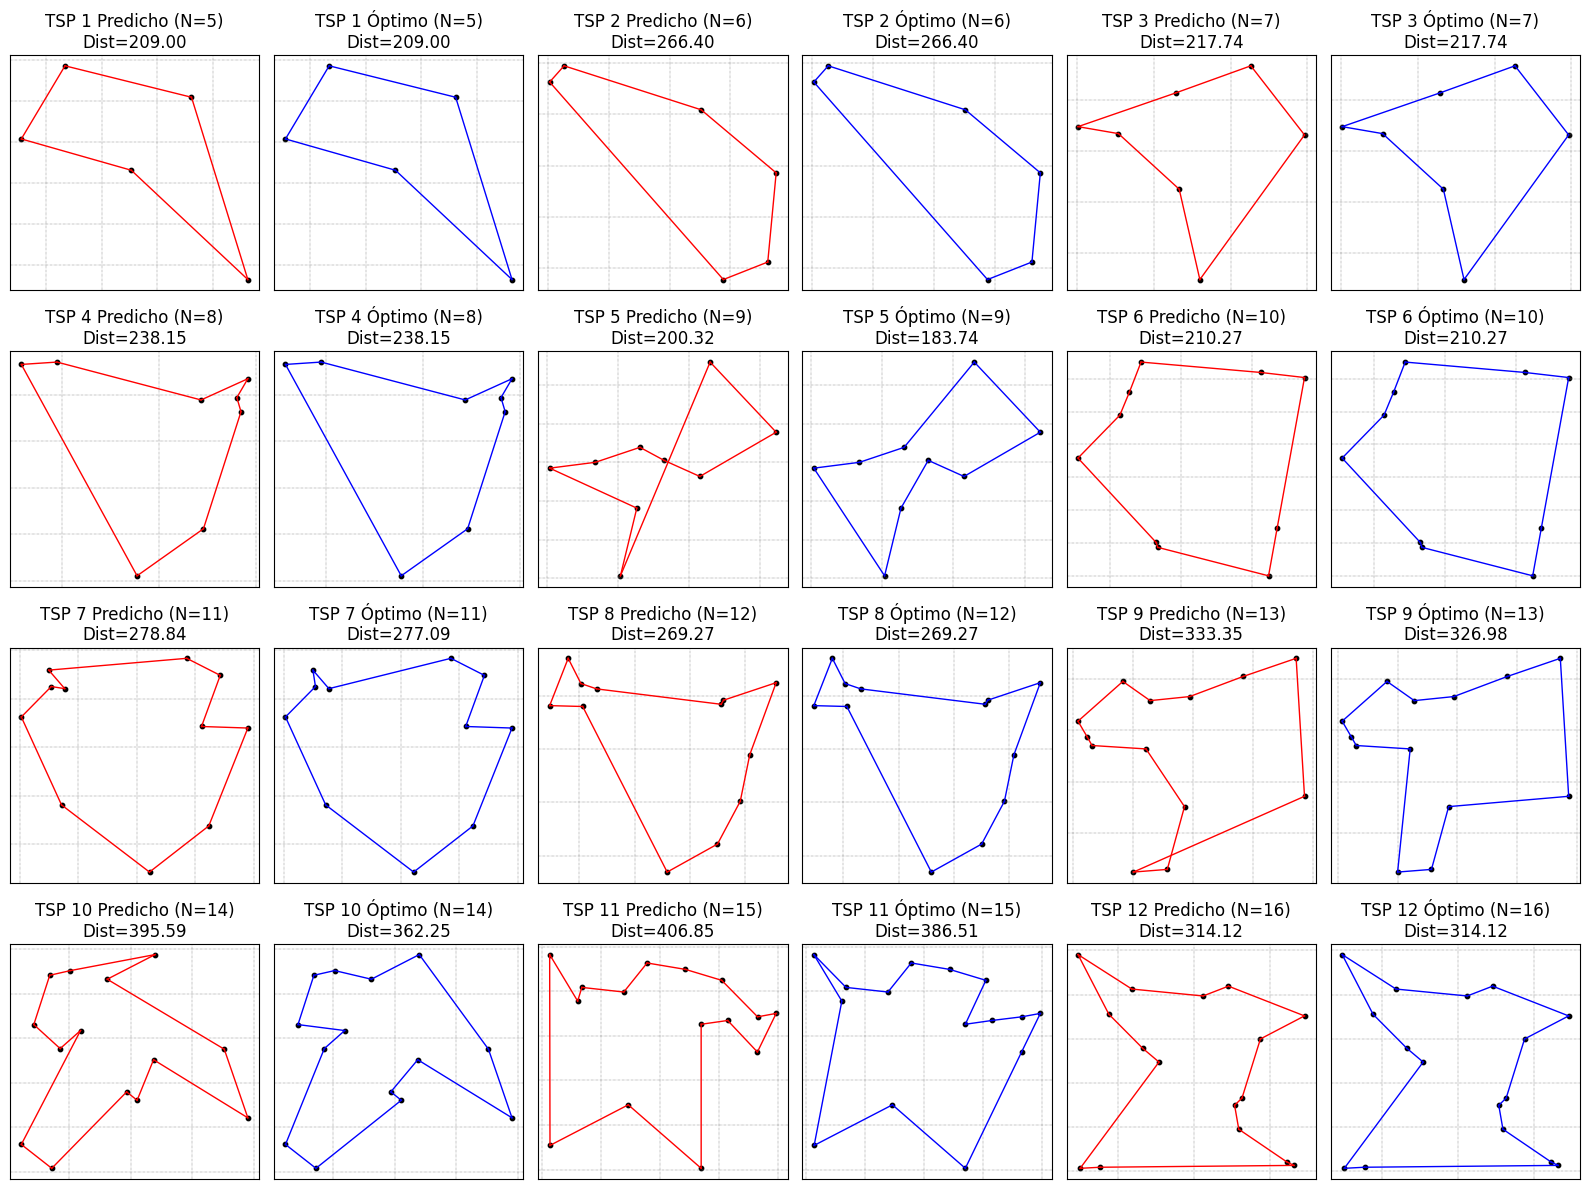

In [19]:
import matplotlib.pyplot as plt

n_instances = len(coords_list)  
n_cols = 6
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))

for idx in range(n_instances):
    row = idx // 3
    col_start = (idx % 3) * 2

    coords = coords_list[idx].numpy()      
    tour_uncross = tour_uncross_list[idx]  
    true_path = true_path_list[idx]        
    pred_distance = pred_dist_list[idx]
    true_distance = true_dist_list[idx]
    num_nodes = num_nodes_list[idx]

    # ——— Subplot Tour Predicho ———
    ax_pred = axes[row, col_start]
    ax_pred.scatter(coords[:, 0], coords[:, 1], color='k', s=10, marker='o')
    for k in range(len(tour_uncross) - 1):
        i = int(tour_uncross[k])
        j = int(tour_uncross[k + 1])
        if 0 <= i < num_nodes and 0 <= j < num_nodes:
            ax_pred.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color='r', linewidth=1
            )
    ax_pred.grid(color='gray', linestyle='-.', linewidth=0.3)
    ax_pred.tick_params(
        axis='both',
        which='both',
        labelbottom=False,
        labelleft=False,
        length=0
    )
    ax_pred.set_title(
        f"TSP {idx+1} Predicho (N={num_nodes})\nDist={pred_distance:.2f}",
        fontsize=12
    )

    # ——— Subplot Tour Óptimo ———
    ax_true = axes[row, col_start + 1]
    ax_true.scatter(coords[:, 0], coords[:, 1], color='k', s=10, marker='o')
    if true_path[0] != true_path[-1]:
        tp = true_path + [true_path[0]]
    else:
        tp = true_path
    for k in range(len(tp) - 1):
        i = int(tp[k])
        j = int(tp[k + 1])
        if 0 <= i < num_nodes and 0 <= j < num_nodes:
            ax_true.plot(
                [coords[i, 0], coords[j, 0]],
                [coords[i, 1], coords[j, 1]],
                color='b', linewidth=1
            )
    # Activar grid gris y fino:
    ax_true.grid(color='gray', linestyle='-.', linewidth=0.3)
    # Quitar solo etiquetas, no las marcas:
    ax_true.tick_params(
        axis='both',
        which='both',
        labelbottom=False,
        labelleft=False,
        length=0
    )
    ax_true.set_title(
        f"TSP {idx+1} Óptimo (N={num_nodes})\nDist={true_distance:.2f}",
        fontsize=12
    )

plt.tight_layout()
plt.show()


In [18]:
# descarga de la Base de Datos de pruebas 
data_prueba = torch.load("TSP_data/test100.pt", weights_only=False)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Carga del modelo 
model = GNN(2, 1, 128, decoder="edge_nodes_emb", use_edge_weight=True).to(device)
model.load_state_dict(torch.load(
    "trained_models/model_2_hd128_lr0.001_ep32_dec_edge_nodes_emb.pt",
    map_location=device
))
model.eval()

# Listas para guardar resultados
coords_list       = []  
tour_uncross_list = []  
true_path_list    = []  
pred_dist_list    = [] 
true_dist_list    = []  
num_nodes_list    = []  

for idx, ejemplo in enumerate(data_prueba):
    # 1) Extraer coordenadas, matriz de distancias y solución óptima de este ejemplo
    coords_tensor    = ejemplo.x                
    dist_matrices    = ejemplo.disntace_matrices
    true_path_tensor = ejemplo.true_path        
    true_distance_t  = ejemplo.true_distance    
    
    # Convertimos a tipos Python / NumPy cuando haga falta:
    coords = coords_tensor.to(device)  # para el modelo, lo mantenemos en device
    num_nodes = coords.shape[0]
    
    # Distancia óptima como float
    if torch.is_tensor(true_distance_t):
        true_distance = true_distance_t.view(-1).cpu().item()
    else:
        true_distance = float(true_distance_t)
    
    # El camino óptimo como lista de ints (solo para imprimir más tarde)
    true_path = true_path_tensor.view(-1).tolist()
    
    # Recogemos la matriz de distancias: dist_matrices puede ser lista/tensor
    if isinstance(dist_matrices, (list, tuple)):
        dist_mat = dist_matrices[0]
    else:
        dist_mat = dist_matrices[0]
    
    # 3) Construir el grafo completo (las aristas i≠j)
    edges = [(i, j) for i in range(num_nodes) for j in range(num_nodes) if i != j]
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)  
    
    # 4) Para cada arista (i,j) extraemos dist_mat[i,j] y formamos edge_attr, edge_weight
    edge_attr_list = []
    for (i, j) in edges:
        dij = dist_mat[i, j].item() if torch.is_tensor(dist_mat) else dist_mat[i][j]
        edge_attr_list.append([dij])
    edge_attr = torch.tensor(edge_attr_list, dtype=torch.float).to(device)     
    edge_weight = edge_attr.clone() 
    
    # Preparamos el objeto Data de PyG
    batch = torch.zeros(num_nodes, dtype=torch.long).to(device)
    data = Data(
        x          = coords,         
        edge_index = edge_index,     
        edge_attr  = edge_attr,      
        edge_weight= edge_weight,    
        batch      = batch           
    )
    
    # Forward de la red para obtener logits → probs
    with torch.no_grad():
        logits = model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.edge_weight,
             data.batch
        )
        probs = torch.sigmoid(logits).view(-1).cpu().numpy() 
    
    # Reconstrucción del tour predicho 
    tour_pred = SolutionAnalysys.tour_from_probs(probs, num_nodes)
    coords_py = coords_tensor.cpu().tolist()  
    uncorner = Opt(coords_py)
    tour_pred= uncorner.uncross(tour_pred)
    
    # 9) Calcular distancia total del tour descruzado
    dist_pred = 0.0
    for k in range(len(tour_pred) - 1):
        i, j = tour_pred[k], tour_pred[k + 1]
        d_ij = dist_mat[i, j].item() if torch.is_tensor(dist_mat) else dist_mat[i][j]
        dist_pred += d_ij

    coords_list.append(coords_tensor.cpu())    
    tour_uncross_list.append(tour_pred)
    true_path_list.append(true_path)
    pred_dist_list.append(dist_pred)
    true_dist_list.append(true_distance)
    num_nodes_list.append(num_nodes)
    
    # 10) Imprimir resultados para esta instancia
    print(f"\n—— TSP {idx+1}/{len(data_prueba)} :")
    print(f"Tour predicho : {tour_pred}")
    print(f"Tour óptimo:  {true_path}")
    print(f"Distancia predicha: {dist_pred:.2f}   |   Distancia óptima: {true_distance:.2f}")
    print(f"Gap relativo: {abs((dist_pred - true_distance)/true_distance * 100):.2f}%")


—— TSP 1/400 :
Tour predicho : [0, 2, 3, 1, 4, 0]
Tour óptimo:  [0.0, 2.0, 3.0, 1.0, 4.0]
Distancia predicha: 274.03   |   Distancia óptima: 274.03
Gap relativo: 0.00%

—— TSP 2/400 :
Tour predicho : [0, 2, 3, 1, 4, 0]
Tour óptimo:  [0.0, 3.0, 1.0, 4.0, 2.0]
Distancia predicha: 274.03   |   Distancia óptima: 232.59
Gap relativo: 17.82%

—— TSP 3/400 :
Tour predicho : [0, 2, 3, 1, 4, 0]
Tour óptimo:  [0.0, 2.0, 1.0, 3.0, 4.0]
Distancia predicha: 274.03   |   Distancia óptima: 227.81
Gap relativo: 20.29%

—— TSP 4/400 :
Tour predicho : [0, 2, 1, 3, 4, 0]
Tour óptimo:  [0.0, 2.0, 1.0, 3.0, 4.0]
Distancia predicha: 364.89   |   Distancia óptima: 201.27
Gap relativo: 81.30%

—— TSP 5/400 :
Tour predicho : [0, 2, 3, 1, 4, 0]
Tour óptimo:  [0.0, 2.0, 3.0, 4.0, 1.0]
Distancia predicha: 274.03   |   Distancia óptima: 243.63
Gap relativo: 12.48%

—— TSP 6/400 :
Tour predicho : [0, 2, 3, 1, 4, 0]
Tour óptimo:  [0.0, 2.0, 1.0, 4.0, 3.0]
Distancia predicha: 274.03   |   Distancia óptima: 155.27
Ga

In [21]:
gaps = [abs((p - t) / t) * 100 for p, t in zip(pred_dist_list, true_dist_list)]
mean_gap = sum(gaps) / len(gaps)
print(f"Gap relativo medio: {mean_gap:.2f}%")


Gap relativo medio: 10.20%


**Vamos a probar con un TSP famoso de mayor tamaño, a ver qué solución nos da**

In [ ]:
# --- 0) Carga y procesa a280 con FamousTSP ----------------------------
a280 = FamousTSP('TSP_problems/berlin52.tsp', 'TSP_problems/berlin52.opt.tour')

# Extrae coords_list_280 y D_280 como antes
nodes = sorted(a280.coords.keys())  
coords_list = [[a280.coords[i][0], a280.coords[i][1]] for i in nodes]
D_full = np.array(a280.dist_matrix)                # shape (281,281)
D_280 = D_full[1:a280.dimension+1,1:a280.dimension+1]  # recorta fila/columna 0

# (Si tuviste que eliminar duplicados, hazlo aquí,
#  y ajusta coords_list_280 y D_280 en paralelo)

# Usa las versiones finales:
coords_list_280 = coords_list
print(coords_list_280)
dist_mat = D_280
coords = torch.tensor(coords_list_280, dtype=torch.float)  # [N,2]
N = coords.size(0)

# --- 1) Construir grafo completo dirigido ---
edges = [(i, j) for i in range(N) for j in range(N) if i != j]
edge_index  = torch.tensor(edges, dtype=torch.long).t().contiguous()  # [2, E]
edge_attr   = torch.tensor([[dist_mat[i, j]] for i, j in edges], dtype=torch.float)  # [E,1]
edge_weight = edge_attr.clone()

# --- 2) Extraer tour óptimo (lista de nodos) ---
# `a280.tour` es la lista 1-based; la pasamos a 0-based:
tour_1_based = a280.tour
tour_zero_based = [v - 1 for v in tour_1_based]
tour_zero_based.append(tour_zero_based[0])  # cerrar ciclo

# --- 3) Crear objeto Data para PyG ---
batch = torch.zeros(N, dtype=torch.long)  # un solo grafo
data_a280 = Data(
    x=coords,
    edge_index=edge_index,
    edge_attr=edge_attr,
    edge_weight=edge_weight,
    batch=batch,
)

# Añadir atributos extra
data_a280.true_path       = torch.tensor(tour_zero_based, dtype=torch.long)
# Calcula la distancia total del tour a partir de dist_mat
total_dist = sum(dist_mat[tour_zero_based[k], tour_zero_based[k+1]] 
                 for k in range(N))
data_a280.true_distance   = torch.tensor([total_dist], dtype=torch.float)
data_a280.pos_class_weight = ((N*(N-1) - N) / N)  


[[565.0, 575.0], [25.0, 185.0], [345.0, 750.0], [945.0, 685.0], [845.0, 655.0], [880.0, 660.0], [25.0, 230.0], [525.0, 1000.0], [580.0, 1175.0], [650.0, 1130.0], [1605.0, 620.0], [1220.0, 580.0], [1465.0, 200.0], [1530.0, 5.0], [845.0, 680.0], [725.0, 370.0], [145.0, 665.0], [415.0, 635.0], [510.0, 875.0], [560.0, 365.0], [300.0, 465.0], [520.0, 585.0], [480.0, 415.0], [835.0, 625.0], [975.0, 580.0], [1215.0, 245.0], [1320.0, 315.0], [1250.0, 400.0], [660.0, 180.0], [410.0, 250.0], [420.0, 555.0], [575.0, 665.0], [1150.0, 1160.0], [700.0, 580.0], [685.0, 595.0], [685.0, 610.0], [770.0, 610.0], [795.0, 645.0], [720.0, 635.0], [760.0, 650.0], [475.0, 960.0], [95.0, 260.0], [875.0, 920.0], [700.0, 500.0], [555.0, 815.0], [830.0, 485.0], [1170.0, 65.0], [830.0, 610.0], [605.0, 625.0], [595.0, 360.0], [1340.0, 725.0], [1740.0, 245.0]]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GNN(
    node_input_dim=2,
    edge_input_dim=1,
    hidden_dim=128,
    decoder="edge_nodes_emb",
    use_edge_weight=True
).to(device)
model.load_state_dict(torch.load(
    "trained_models/model_2_hd128_lr0.001_ep32_dec_edge_nodes_emb.pt",
    map_location=device
))
model.eval()

# --- 1) Forward + logits/probs ---
with torch.no_grad():
    logits = model(
        data_a280.x.to(device),
        data_a280.edge_index.to(device),
        data_a280.edge_attr.to(device),
        data_a280.edge_weight.to(device),
        data_a280.batch.to(device)
    )  # [E,1]
probs = torch.sigmoid(logits).view(-1)  # [E]

tour = SolutionAnalysys.tour_from_probs(probs, len(nodes))

uncorner = Opt(coords_list_280)
tour = uncorner.uncross(tour)

# --- 3) Cálculo de métricas usando dist_mat y data_a280.true_distance ---
pred_len = sum(dist_mat[tour[k], tour[k+1]] for k in range(N))
true_len = data_a280.true_distance.item()
opt_gap = (pred_len - true_len) / true_len


# --- 4) Impresión final ---
print("Tour óptimo real:   ", data_a280.true_path.tolist())
print("Tour predicho:      ", tour)
print(f"Longitud real:      {true_len:.2f}")
print(f"Longitud predicha:  {pred_len:.2f}")
print(f"Optimality gap:     {opt_gap*100:.2f}%")

Tour óptimo real:    [0, 48, 31, 44, 18, 40, 7, 8, 9, 42, 32, 50, 10, 51, 13, 12, 46, 25, 26, 27, 11, 24, 3, 5, 14, 4, 23, 47, 37, 36, 39, 38, 35, 34, 33, 43, 45, 15, 28, 49, 19, 22, 29, 1, 6, 41, 20, 16, 2, 17, 30, 21, 0]
Tour predicho:       [0, 49, 51, 50, 48, 47, 46, 45, 44, 43, 42, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 15, 14, 13, 12, 11, 10, 9, 8, 7, 5, 4, 3, 2, 41, 6, 1, 16, 17, 18, 22, 21, 20, 19, 0]
Longitud real:      7542.00
Longitud predicha:  18426.00
Optimality gap:     144.31%


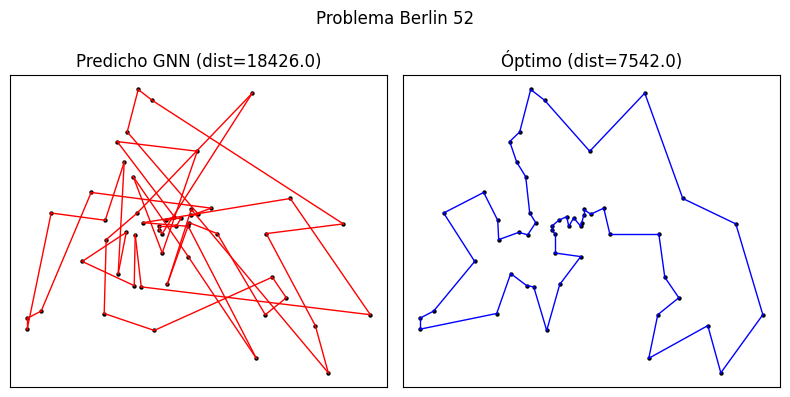

In [ ]:
# 6) Visualización comparativa con puntos más pequeños
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle("Problema Berlin 52", fontsize=12)
coords_np = data_a280.x.cpu().numpy()

# Predicho
ax = axes[0]
ax.scatter(coords_np[:,0], coords_np[:,1],
           color='k', s=10, marker='o', linewidths=0)
for a, b in zip(tour[:-1], tour[1:]):
    ax.plot([coords_np[a,0], coords_np[b,0]],
            [coords_np[a,1], coords_np[b,1]],
            c='r', linewidth=1)
ax.set_title(f"Predicho GNN (dist={pred_len:.1f})")
ax.set_xticks([]); ax.set_yticks([])

# Óptimo
ax = axes[1]
ax.scatter(coords_np[:,0], coords_np[:,1], color='k', s=10, marker='o', linewidths=0)
for a, b in zip(data_a280.true_path[:-1], data_a280.true_path[1:]):
    ax.plot([coords_np[a,0], coords_np[b,0]],
            [coords_np[a,1], coords_np[b,1]],
            c='b', linewidth=1)
ax.set_title(f"Óptimo (dist={true_len:.1f})")
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()